<a href="https://www.kaggle.com/code/kedhareswernaidu/forecasting-sticker-sales?scriptVersionId=228529595" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [2]:
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")


## Data Loading

In [3]:
train = pd.read_csv('/kaggle/input/playground-series-s5e1/train.csv', index_col=0)

In [4]:
test = pd.read_csv('/kaggle/input/playground-series-s5e1/test.csv', index_col=0)

In [5]:
print('The dimension of the train dataset is:', train.shape)
print('The dimension of the test dataset is:', test.shape)

The dimension of the train dataset is: (230130, 5)
The dimension of the test dataset is: (98550, 4)


In [6]:
train.head()

,date,country,store,product,num_sold
id,,,,,
0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0
3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0
4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0


In [7]:
test.head()

,date,country,store,product
id,,,,
230130,2017-01-01,Canada,Discount Stickers,Holographic Goose
230131,2017-01-01,Canada,Discount Stickers,Kaggle
230132,2017-01-01,Canada,Discount Stickers,Kaggle Tiers
230133,2017-01-01,Canada,Discount Stickers,Kerneler
230134,2017-01-01,Canada,Discount Stickers,Kerneler Dark Mode


In [8]:
import pandas as pd

def missing_percentage(df):
    missing_data = df.isnull().sum()  # Count missing values per column
    total_data = df.shape[0]  # Total number of rows
    missing_percentage = (missing_data / total_data) * 100  # Calculate percentage of missing values
    return missing_percentage

In [9]:
#Missing values percentage in train
missing_percentage(train)

date        0.000000
country     0.000000
store       0.000000
product     0.000000
num_sold    3.854778
dtype: float64

In [10]:
#Missing values percentage in test
missing_percentage(test)

date       0.0
country    0.0
store      0.0
product    0.0
dtype: float64

Missing values in "num_sold" in Train data

In [11]:
train = train.dropna().reset_index(drop=True)

In [12]:
missing_percentage(train)

date        0.0
country     0.0
store       0.0
product     0.0
num_sold    0.0
dtype: float64

In [13]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
num_sold,221259.0,752.527382,690.165445,5.0,219.0,605.0,1114.0,5939.0


In [14]:
train.date.dtype

dtype('O')

In [15]:
train['date']= pd.to_datetime(train['date'])

In [16]:
train.date.dtype

dtype('<M8[ns]')

In [17]:
test['date'] = pd.to_datetime(test['date'])

In [18]:
train.describe().T

,count,mean,min,25%,50%,75%,max,std
date,221259,2013-07-05 16:57:47.964692736,2010-01-01 00:00:00,2011-10-09 00:00:00,2013-07-07 00:00:00,2015-04-03 00:00:00,2016-12-31 00:00:00,NaN
num_sold,221259.0,752.527382,5.0,219.0,605.0,1114.0,5939.0,690.165445


## Data Exploration

### General Analysis

Let's try to get as much insights as possible for the data

In [19]:
print(train['country'].value_counts())

country
Finland      38355
Italy        38355
Singapore    38355
Norway       38355
Canada       34109
Kenya        33730
Name: count, dtype: int64


In [20]:
print(train['product'].value_counts())

product
Kaggle                46026
Kaggle Tiers          46026
Kerneler Dark Mode    46025
Kerneler              45962
Holographic Goose     37220
Name: count, dtype: int64


In [21]:
print(train['store'].value_counts())

store
Premium Sticker Mart    75684
Stickers for Less       74044
Discount Stickers       71531
Name: count, dtype: int64


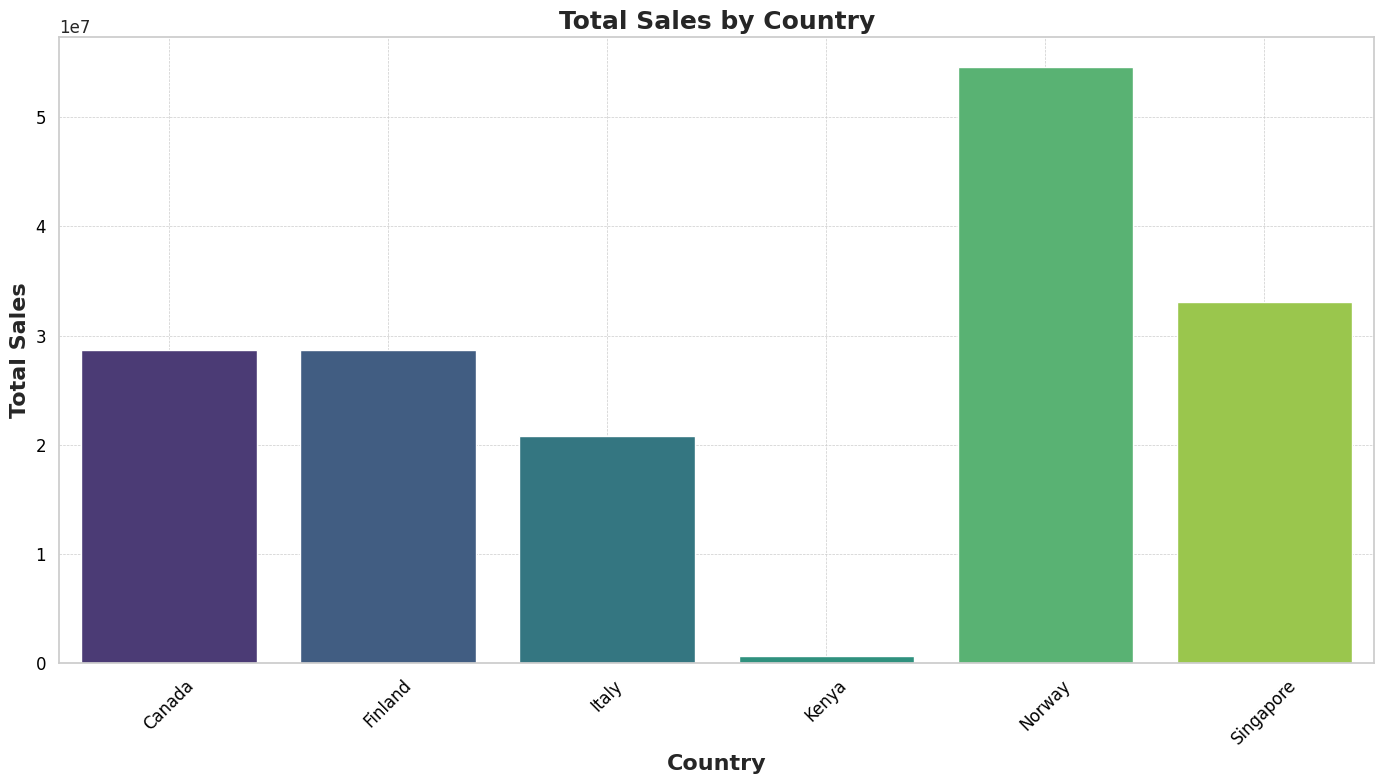

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn style
sns.set(style='whitegrid')

# Group by country and sum the sales
sales_by_country = train.groupby('country')['num_sold'].sum().reset_index()

# Create a figure with a specific size and style
plt.figure(figsize=(14, 8))
plt.rc('axes', titlesize=16, titleweight='bold')  # Customize title size and weight
plt.rc('axes', labelsize=14, labelweight='bold')  # Customize label size and weight
plt.rc('xtick', labelsize=12)  # Customize x-tick label size
plt.rc('ytick', labelsize=12)  # Customize y-tick label size

# Plot sales by country
sns.barplot(data=sales_by_country, x='country', y='num_sold', palette='viridis')
plt.title('Total Sales by Country', fontsize=18, fontweight='bold')
plt.xlabel('Country', fontsize=16, fontweight='bold')
plt.ylabel('Total Sales', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, fontsize=12, color='black')
plt.yticks(fontsize=12, color='black')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

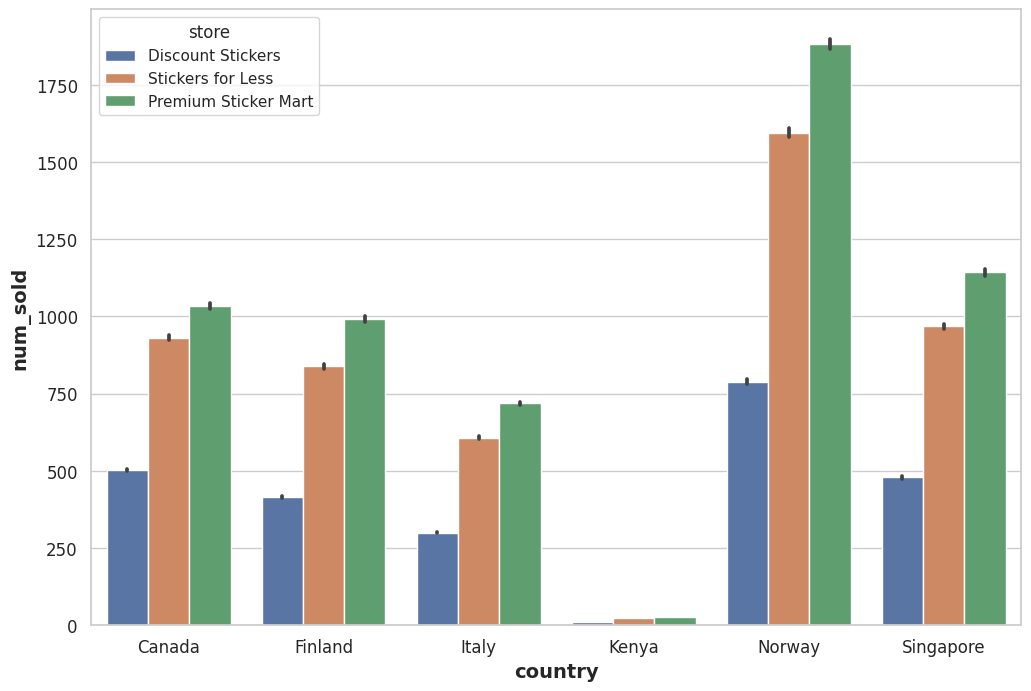

In [23]:
plt.figure(figsize = (12, 8))
ax = sns.barplot(data=train, x='country', y='num_sold', hue='store')

* Canada: "Premium Sticker Mart" leads with the highest sales, followed by "Stickers for Less" and "Discount Stickers."

* Finland: Similar trend with "Premium Sticker Mart" in first place, "Stickers for Less" in second, and "Discount Stickers" in third.

* Italy: "Premium Sticker Mart" again dominates the sales, followed by the other two stores.

* Kenya: All three stores sold very few stickers, but "Discount Stickers" has a slight lead.

* Norway: "Premium Sticker Mart" sold the most stickers, followed by "Stickers for Less" and "Discount Stickers."

* Singapore: "Premium Sticker Mart" tops the sales,followed by "Stickers for Less" and "Discount Stickers."

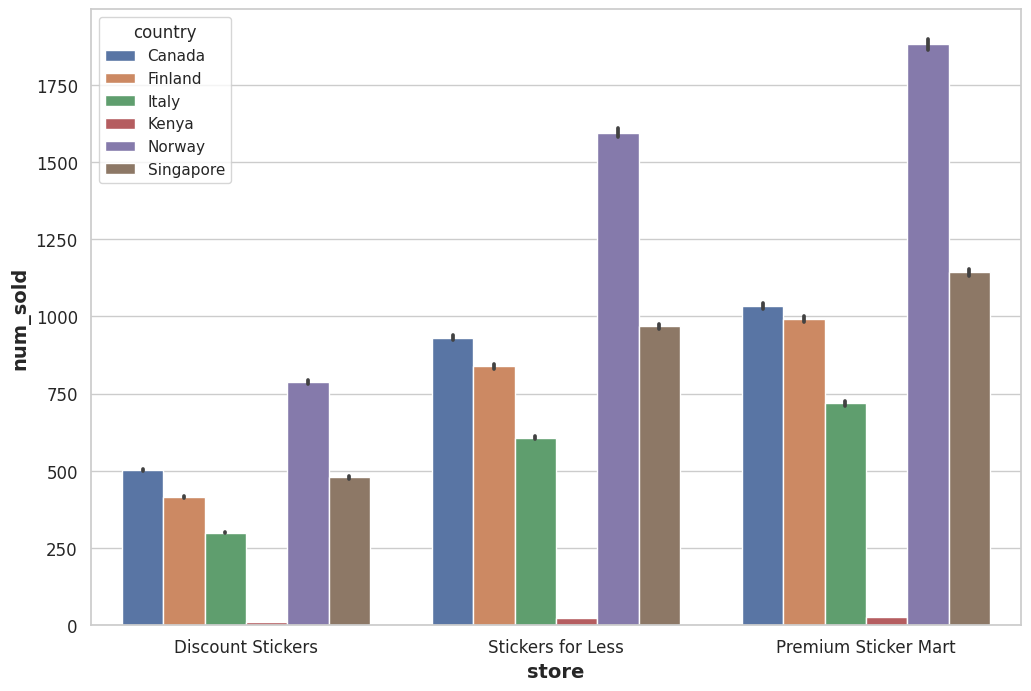

In [24]:
plt.figure(figsize = (12, 8))
ax = sns.barplot(data=train, x='store', y='num_sold', hue='country')

* Canada: Premium Sticker Mart sells the most stickers, followed by Stickers for Less and Discount Stickers.

* Finland: Premium Sticker Mart again leads, with Stickers for Less in second place.

* Italy: The trend remains, with Premium Sticker Mart topping the sales.

* Kenya: All three stores have low sales, with Discount Stickers slightly ahead.

* Norway: Premium Sticker Mart has the highest sales, with a significant margin over the others.

* Singapore: Premium Sticker Mart leads, followed by Stickers for Less.

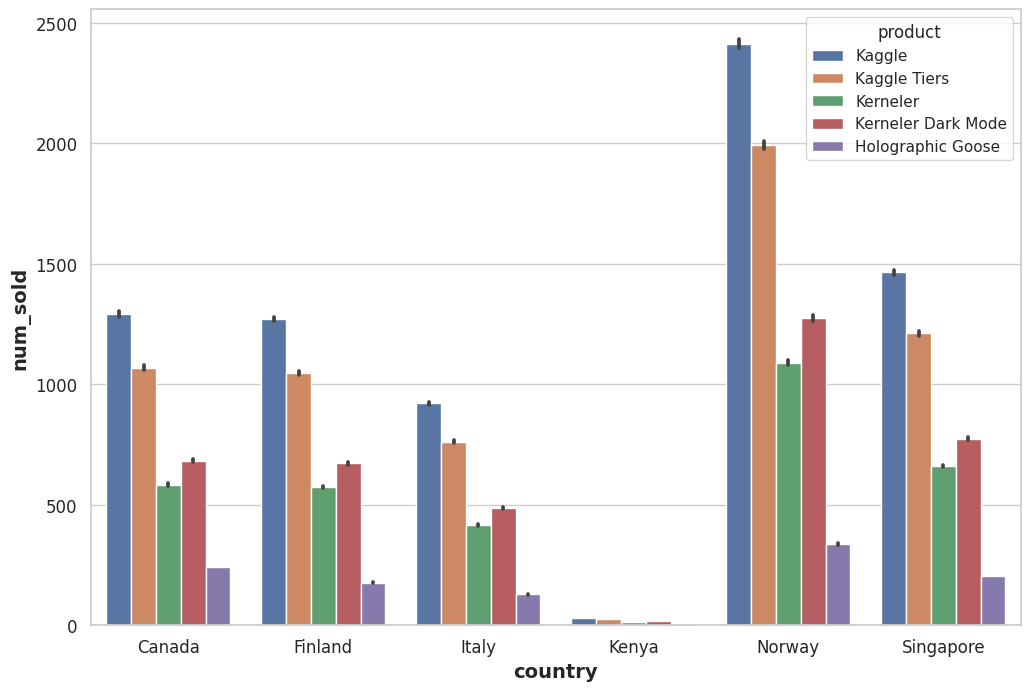

In [25]:
plt.figure(figsize = (12, 8))
ax = sns.barplot(data=train, x='country', y='num_sold', hue='product')

* Canada: "Kaggle" is the top-seller, followed by "Kaggle Tiers" and other products.

* Finland: Similar trends with high sales for "Kaggle" and "Kaggle Tiers."

* Italy: "Kaggle" leads again, showing its popularity.

* Kenya: Sales are minimal across all products, indicating a potential market gap or lack of demand.

* Norway: Highest overall sales for "Kaggle" and "Kaggle Tiers," making it a strong market for these products.

* Singapore: Consistent performance with "Kaggle" leading the charts.

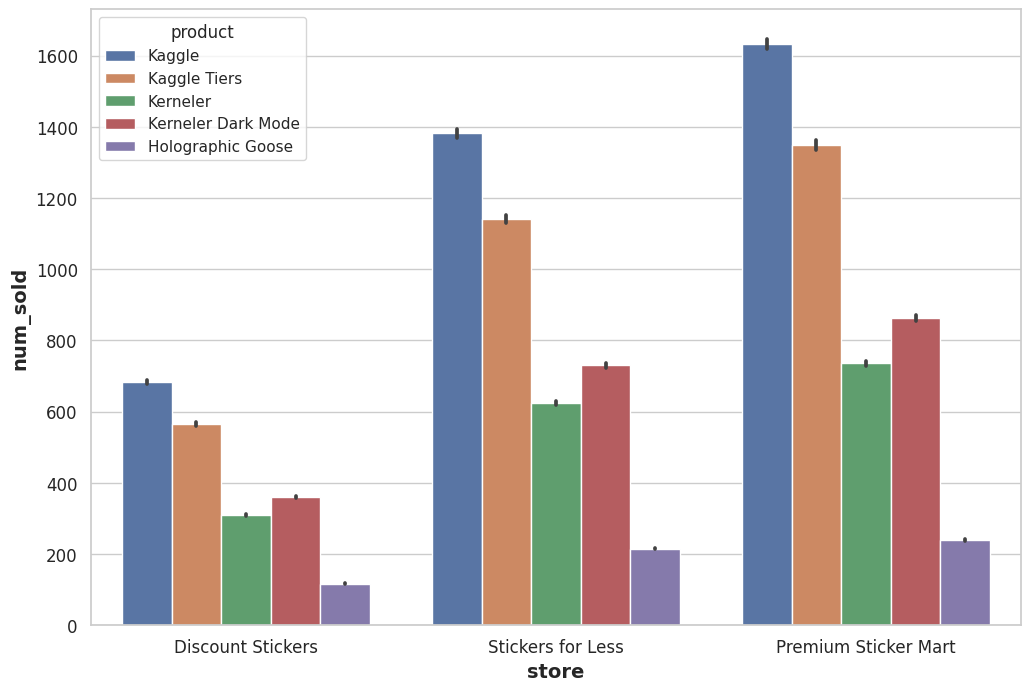

In [26]:
plt.figure(figsize = (12, 8))
ax = sns.barplot(data=train, x='store', y='num_sold', hue='product')

#### Key Observations:
1. Top Performing Store:

* Premium Sticker Mart consistently leads in sales across almost all countries, indicating a strong brand presence and customer preference.

* Stickers for Less generally performs better than Discount Stickers but trails behind Premium Sticker Mart.

* Discount Stickers has the lowest sales in most countries, suggesting a need for improvement in marketing or product offerings.

2. Country-Specific Insights:

* Canada: Premium Sticker Mart tops the sales, followed by Stickers for Less and Discount Stickers.

* Finland: The trend is similar, with Premium Sticker Mart leading the sales.

* Italy: Premium Sticker Mart continues to dominate the sales, showcasing its popularity.

* Kenya: Sales are notably low across all stores, with Discount Stickers having a slight lead.

* Norway: Premium Sticker Mart has the highest sales, followed by Stickers for Less and Discount Stickers.

* Singapore: Premium Sticker Mart leads the sales, with Stickers for Less in second place.

3. Market Gaps:

* Kenya: All three stores have low sales, indicating a potential market gap. Targeted marketing efforts might be needed to boost sales in this region.

* Discount Stickers: Generally has the lowest sales across most countries, suggesting it may need to improve its product offerings or marketing strategies.

### Timeseries Analysis

In [27]:
train.head()

,date,country,store,product,num_sold
0,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
1,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0
2,2010-01-01,Canada,Discount Stickers,Kerneler,423.0
3,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0
4,2010-01-01,Canada,Stickers for Less,Holographic Goose,300.0


In [28]:
df = train.copy()

In [29]:
# Set the date column as the index
df.set_index('date', inplace=True)

In [30]:
df.head()

,country,store,product,num_sold
date,,,,
2010-01-01,Canada,Discount Stickers,Kaggle,973.0
2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0
2010-01-01,Canada,Discount Stickers,Kerneler,423.0
2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0
2010-01-01,Canada,Stickers for Less,Holographic Goose,300.0


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 221259 entries, 2010-01-01 to 2016-12-31
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   country   221259 non-null  object 
 1   store     221259 non-null  object 
 2   product   221259 non-null  object 
 3   num_sold  221259 non-null  float64
dtypes: float64(1), object(3)
memory usage: 8.4+ MB


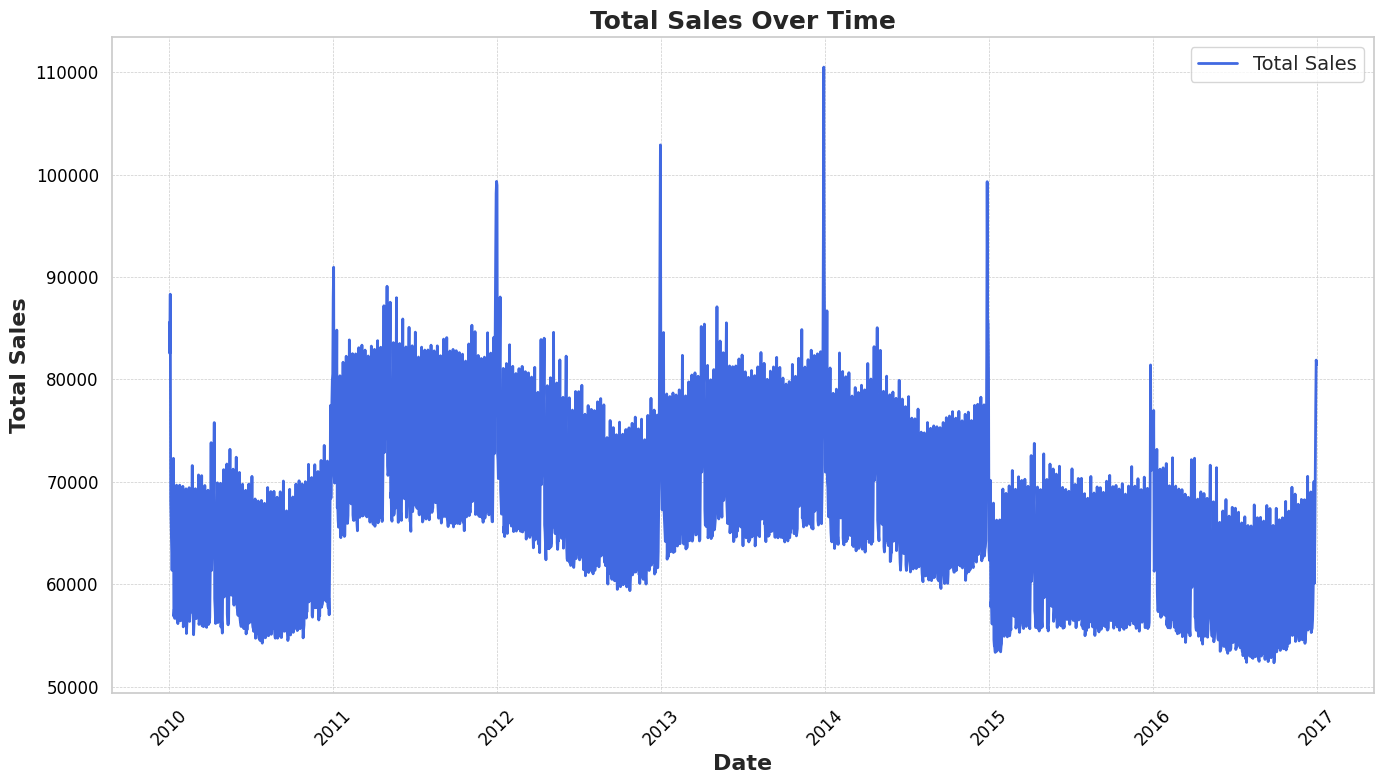

In [32]:
# Set Seaborn style
sns.set(style='whitegrid')

# Group by date and sum sales (total sales over time)
total_sales = df.groupby('date')['num_sold'].sum()

# Create a figure with a specific size and style
plt.figure(figsize=(14, 8))
plt.rc('axes', titlesize=16, titleweight='bold')  # Customize title size and weight
plt.rc('axes', labelsize=14, labelweight='bold')  # Customize label size and weight
plt.rc('xtick', labelsize=12)  # Customize x-tick label size
plt.rc('ytick', labelsize=12)  # Customize y-tick label size

# Plot the total sales over time
plt.plot(total_sales, label='Total Sales', color='royalblue', linewidth=2)
plt.title('Total Sales Over Time', fontsize=18, fontweight='bold')
plt.xlabel('Date', fontsize=16, fontweight='bold')
plt.ylabel('Total Sales', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, fontsize=12, color='black')
plt.yticks(fontsize=12, color='black')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()


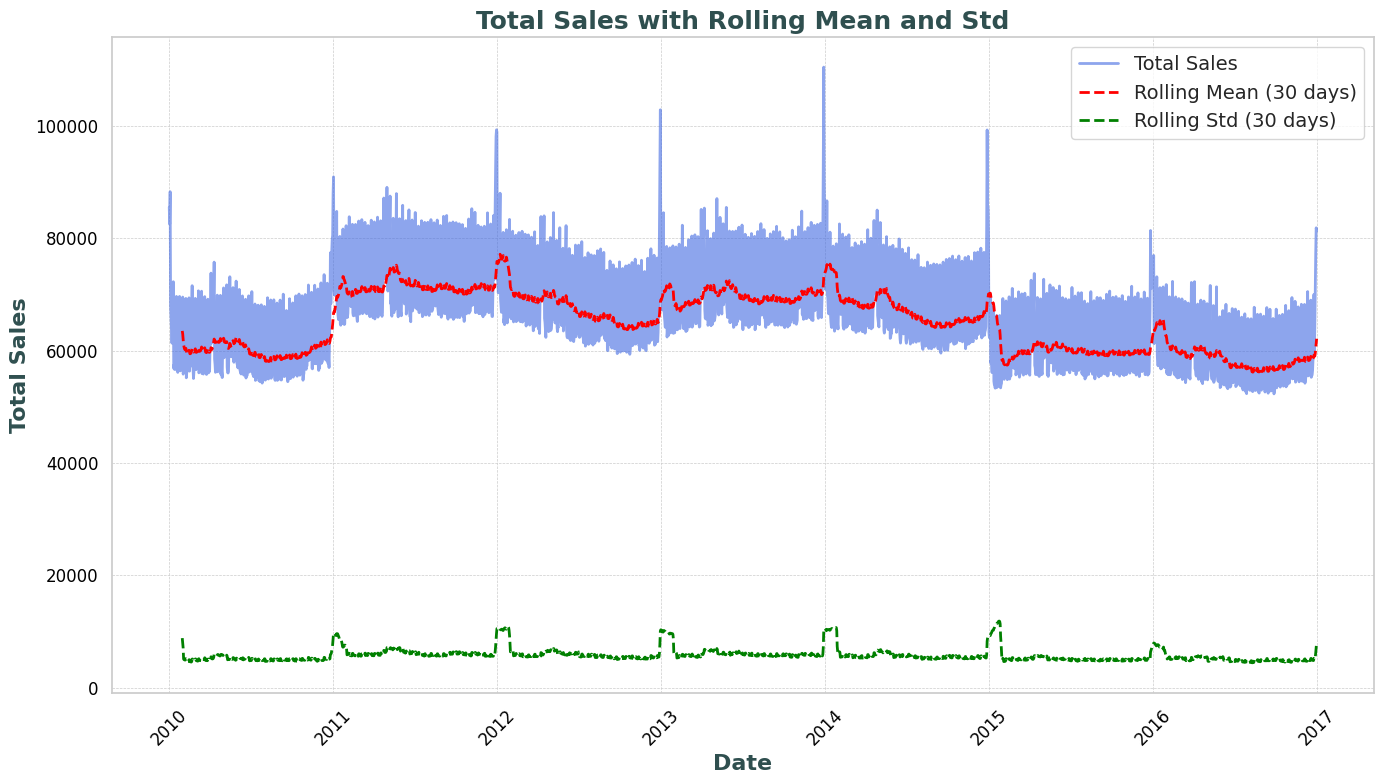

In [33]:
# Set Seaborn style
sns.set(style='whitegrid')

# Calculate the rolling mean and rolling standard deviation
rolling_mean = total_sales.rolling(window=30).mean()  # 30-day window
rolling_std = total_sales.rolling(window=30).std()    # 30-day window

# Create a figure with a specific size and style
plt.figure(figsize=(14, 8))
plt.rc('axes', titlesize=16, titleweight='bold')  # Customize title size and weight
plt.rc('axes', labelsize=14, labelweight='bold')  # Customize label size and weight
plt.rc('xtick', labelsize=12)  # Customize x-tick label size
plt.rc('ytick', labelsize=12)  # Customize y-tick label size

# Plot the total sales, rolling mean, and rolling std
plt.plot(total_sales, label='Total Sales', color='royalblue', alpha=0.6, linewidth=2)
plt.plot(rolling_mean, label='Rolling Mean (30 days)', color='red', linestyle='--', linewidth=2)
plt.plot(rolling_std, label='Rolling Std (30 days)', color='green', linestyle='--', linewidth=2)
plt.title('Total Sales with Rolling Mean and Std', fontsize=18, fontweight='bold', color='darkslategray')
plt.xlabel('Date', fontsize=16, fontweight='bold', color='darkslategray')
plt.ylabel('Total Sales', fontsize=16, fontweight='bold', color='darkslategray')
plt.xticks(rotation=45, fontsize=12, color='black')
plt.yticks(fontsize=12, color='black')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()


##### Key Elements of the Graph:
1. Total Sales (Blue Area):

* This represents the total sales over time, highlighting the fluctuations and peaks in sales from 2010 to 2017.

* The blue area shows significant seasonal peaks, particularly towards the end of each year, indicating possible seasonal demand.

2. Rolling Mean (Red Line):

* The red line represents the 30-day rolling mean, which smooths out short-term fluctuations and provides a clearer view of the longer-term trend.

* This helps to understand the overall direction of sales, reducing the noise from daily variations.

3. Rolling Std (Green Dashed Line):

* The green dashed line shows the 30-day rolling standard deviation, indicating the variability in sales over time.

* Higher peaks in the rolling standard deviation suggest periods of greater volatility in sales, while lower values indicate more stable sales periods.

##### Insights and Interpretation:
1. Seasonality: The graph shows pronounced seasonal patterns, with notable peaks towards the end of each year. This suggests that there are certain times of the year when sales consistently increase, possibly due to holidays or special events.

2. Trends: The rolling mean (red line) helps to highlight the overall upward or downward trends in sales over the given period. For example, if the red line generally slopes upwards, it indicates that total sales are increasing over time.

3. Volatility: The rolling standard deviation (green dashed line) provides insights into periods of high and low sales volatility. High peaks in the rolling standard deviation indicate periods of significant changes in sales, which could be due to various external factors such as promotions, market conditions, or seasonal variations.

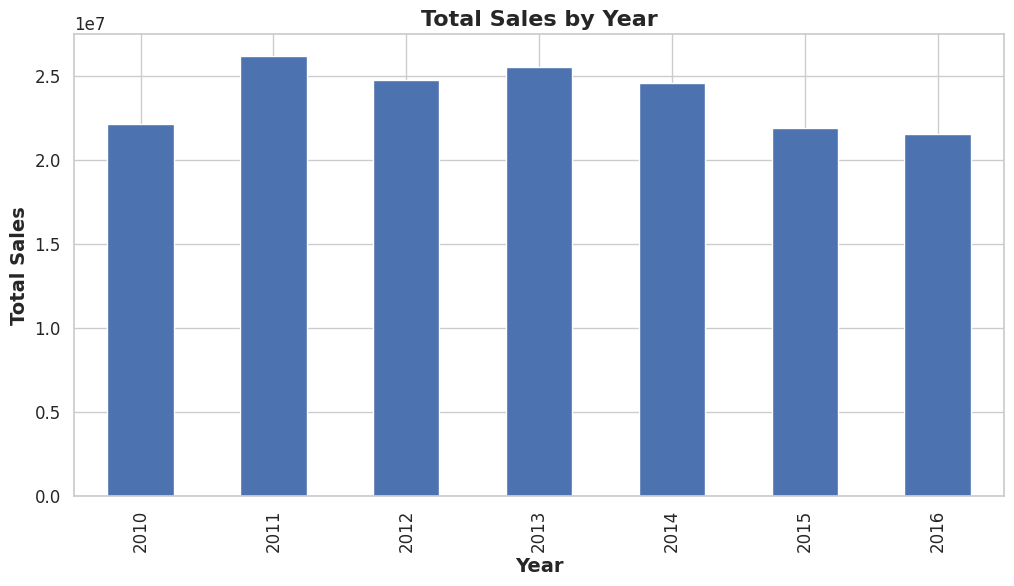

In [34]:
# Extract the year from the index
df['year'] = df.index.year

# Group by year and sum the sales
yearly_sales = df.groupby('year')['num_sold'].sum()

# Plot the yearly sales comparison
plt.figure(figsize=(12, 6))
yearly_sales.plot(kind='bar')
plt.title('Total Sales by Year')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

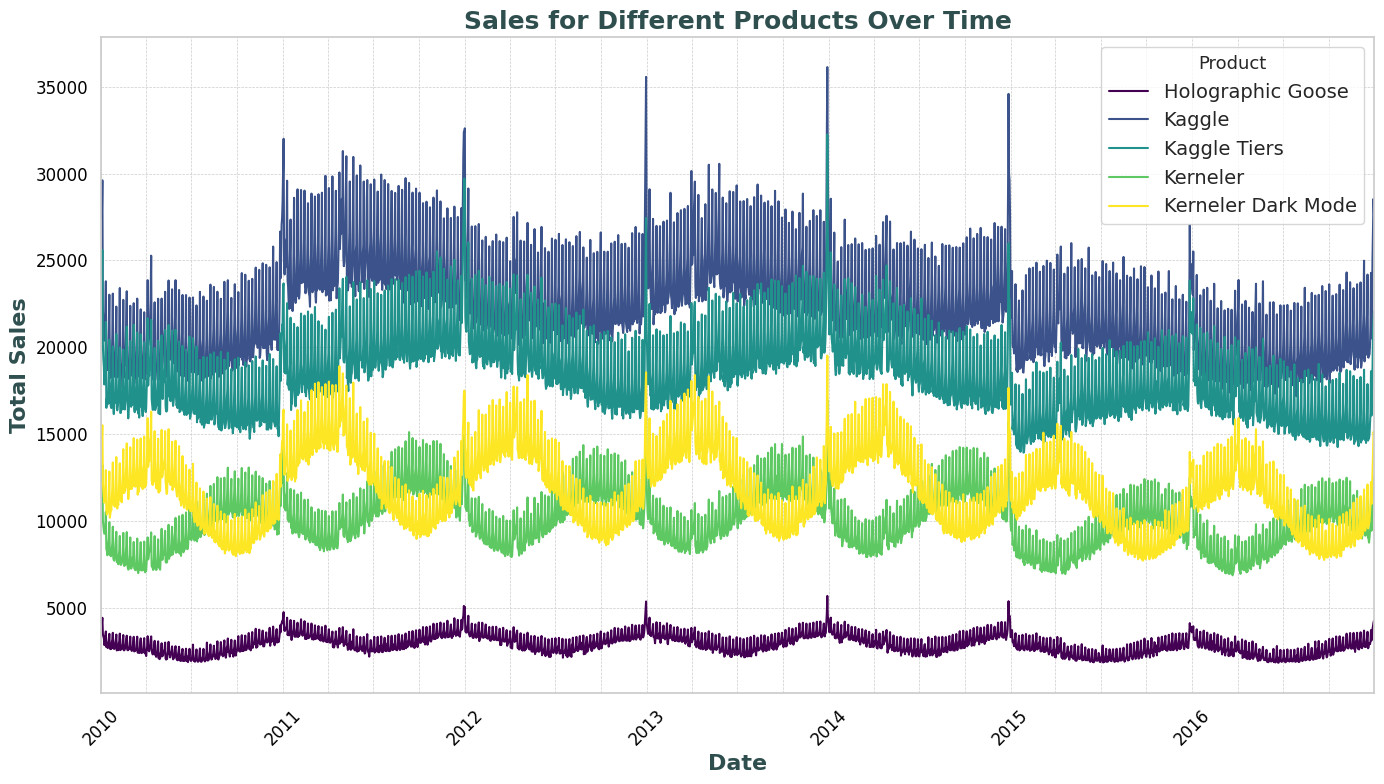

In [35]:
# Set Seaborn style
sns.set(style='whitegrid')

# Create a pivot table with sales by date and product
sales_by_product = df.pivot_table(values='num_sold', index='date', columns='product', aggfunc='sum')

# Create a figure with a specific size and style
plt.figure(figsize=(14, 8))
plt.rc('axes', titlesize=16, titleweight='bold')  # Customize title size and weight
plt.rc('axes', labelsize=14, labelweight='bold')  # Customize label size and weight
plt.rc('xtick', labelsize=12)  # Customize x-tick label size
plt.rc('ytick', labelsize=12)  # Customize y-tick label size

# Plot sales for different products over time
sales_by_product.plot(ax=plt.gca(), colormap='viridis')
plt.title('Sales for Different Products Over Time', fontsize=18, fontweight='bold', color='darkslategray')
plt.xlabel('Date', fontsize=16, fontweight='bold', color='darkslategray')
plt.ylabel('Total Sales', fontsize=16, fontweight='bold', color='darkslategray')
plt.xticks(rotation=45, fontsize=12, color='black')
plt.yticks(fontsize=12, color='black')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(fontsize=14, title='Product', title_fontsize='13')
plt.tight_layout()
plt.show()

##### Key Observations:
1. Products Tracked:

* Holographic Goose (Purple): This product shows significant sales growth with noticeable spikes, indicating periodic high-demand periods.

* Kaggle (Blue): The sales for Kaggle remain relatively steady throughout the period with slight fluctuations.

* Kaggle Tiers (Green): This product sees moderate sales with periodic increases, suggesting seasonal or promotional influences.

* Kerneler (Yellow): Shows a consistent sales pattern with occasional peaks, indicating stable demand.

* Kerneler Dark Mode (Teal): Exhibits a gradual increase in sales, particularly noticeable in the later years.

2. Seasonal Trends:

* Most products exhibit periodic spikes, possibly indicating seasonal demand or promotional events that lead to increased sales.

* These patterns are especially noticeable for Holographic Goose, which has several high peaks.

3. Sales Peaks:

* Each product has distinct periods where sales significantly increase. Understanding the causes of these peaks (e.g., holiday seasons, new product launches, marketing campaigns) can provide valuable insights for future strategies.

4. Product Comparison:

* Holographic Goose appears to be a strong performer with the highest sales spikes.

* Kaggle and Kerneler maintain a steady sales trend, indicating consistent customer interest.

* Kaggle Tiers and Kerneler Dark Mode show varied performance, with Kerneler Dark Mode gaining more traction in the latter years.

## Data Preparation

In [36]:
df.head()

,country,store,product,num_sold,year
date,,,,,
2010-01-01,Canada,Discount Stickers,Kaggle,973.0,2010
2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0,2010
2010-01-01,Canada,Discount Stickers,Kerneler,423.0,2010
2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0,2010
2010-01-01,Canada,Stickers for Less,Holographic Goose,300.0,2010


In [37]:
# Extract time-based features
df['year'] = df.index.year
df['month'] = df.index.month
df['dayofweek'] = df.index.dayofweek
df['quarter'] = df.index.quarter
df['week_of_year'] = df.index.isocalendar().week
df['day_of_month'] = df.index.day
df['is_weekend'] = df.index.dayofweek >= 5  # 5 for Saturday, 6 for Sunday

In [38]:
df.head()

,country,store,product,num_sold,year,month,dayofweek,quarter,week_of_year,day_of_month,is_weekend
date,,,,,,,,,,,
2010-01-01,Canada,Discount Stickers,Kaggle,973.0,2010,1,4,1,53,1,False
2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0,2010,1,4,1,53,1,False
2010-01-01,Canada,Discount Stickers,Kerneler,423.0,2010,1,4,1,53,1,False
2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0,2010,1,4,1,53,1,False
2010-01-01,Canada,Stickers for Less,Holographic Goose,300.0,2010,1,4,1,53,1,False


In [39]:
# Create Lag Features (e.g., sales from the previous day)
df['lag_1'] = df.groupby(['country', 'store', 'product'])['num_sold'].shift(1)
df['lag_2'] = df.groupby(['country', 'store', 'product'])['num_sold'].shift(2)
df['lag_3'] = df.groupby(['country', 'store', 'product'])['num_sold'].shift(3)

In [40]:
df.head()

,country,store,product,num_sold,year,month,dayofweek,quarter,week_of_year,day_of_month,is_weekend,lag_1,lag_2,lag_3
date,,,,,,,,,,,,,,
2010-01-01,Canada,Discount Stickers,Kaggle,973.0,2010,1,4,1,53,1,False,NaN,NaN,NaN
2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0,2010,1,4,1,53,1,False,NaN,NaN,NaN
2010-01-01,Canada,Discount Stickers,Kerneler,423.0,2010,1,4,1,53,1,False,NaN,NaN,NaN
2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0,2010,1,4,1,53,1,False,NaN,NaN,NaN
2010-01-01,Canada,Stickers for Less,Holographic Goose,300.0,2010,1,4,1,53,1,False,NaN,NaN,NaN


In [41]:
# Calculate Daily Sales Difference
df['sales_diff'] = df.groupby(['country', 'store', 'product'])['num_sold'].diff()

In [42]:
df.head()

,country,store,product,num_sold,year,month,dayofweek,quarter,week_of_year,day_of_month,is_weekend,lag_1,lag_2,lag_3,sales_diff
date,,,,,,,,,,,,,,,
2010-01-01,Canada,Discount Stickers,Kaggle,973.0,2010,1,4,1,53,1,False,NaN,NaN,NaN,NaN
2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0,2010,1,4,1,53,1,False,NaN,NaN,NaN,NaN
2010-01-01,Canada,Discount Stickers,Kerneler,423.0,2010,1,4,1,53,1,False,NaN,NaN,NaN,NaN
2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0,2010,1,4,1,53,1,False,NaN,NaN,NaN,NaN
2010-01-01,Canada,Stickers for Less,Holographic Goose,300.0,2010,1,4,1,53,1,False,NaN,NaN,NaN,NaN


In [43]:
pip install holidays

Note: you may need to restart the kernel to use updated packages.


In [44]:
import holidays
# Step 5: Create Holiday Feature (Example for Canada)
ca_holidays = holidays.Canada(years=df['year'].unique())
df['is_holiday'] = df.index.isin(ca_holidays)

# Step 6: Create Time Trend Feature (Days since the start of the dataset)
df['time_trend'] = (df.index - df.index.min()).days

# Drop rows with NaN values in lag or sales_diff columns (optional)
df.dropna(subset=['lag_1', 'sales_diff'], inplace=True)

# Final Preprocessed Data
df.head()

,country,store,product,num_sold,year,month,dayofweek,quarter,week_of_year,day_of_month,is_weekend,lag_1,lag_2,lag_3,sales_diff,is_holiday,time_trend
date,,,,,,,,,,,,,,,,,
2010-01-02,Canada,Discount Stickers,Kaggle,881.0,2010,1,5,1,53,2,True,973.0,NaN,NaN,-92.0,False,1
2010-01-02,Canada,Discount Stickers,Kaggle Tiers,854.0,2010,1,5,1,53,2,True,906.0,NaN,NaN,-52.0,False,1
2010-01-02,Canada,Discount Stickers,Kerneler,440.0,2010,1,5,1,53,2,True,423.0,NaN,NaN,17.0,False,1
2010-01-02,Canada,Discount Stickers,Kerneler Dark Mode,437.0,2010,1,5,1,53,2,True,491.0,NaN,NaN,-54.0,False,1
2010-01-02,Canada,Stickers for Less,Holographic Goose,281.0,2010,1,5,1,53,2,True,300.0,NaN,NaN,-19.0,False,1


In [45]:
missing_percentage(df)

country         0.000000
store           0.000000
product         0.000000
num_sold        0.000000
year            0.000000
month           0.000000
dayofweek       0.000000
quarter         0.000000
week_of_year    0.000000
day_of_month    0.000000
is_weekend      0.000000
lag_1           0.000000
lag_2           0.039788
lag_3           0.079576
sales_diff      0.000000
is_holiday      0.000000
time_trend      0.000000
dtype: float64

In [46]:
df['lag_1_missing'] = df['lag_1'].isnull().astype(int)
df['lag_2_missing'] = df['lag_2'].isnull().astype(int)
df['lag_3_missing'] = df['lag_3'].isnull().astype(int)
df[['lag_1', 'lag_2', 'lag_3']] = df[['lag_1', 'lag_2', 'lag_3']].fillna(0)  # Replace NaN with 0s after adding missing flags

* lag_1_missing, lag_2_missing, lag_3_missing: These columns will contain a 1 if the corresponding lag value is missing (NaN), and 0 if the value is present.
* Filling NaN with 0: After adding the flags, we fill the missing lag values with 0 to ensure that the model can use the data without issues.

In [47]:
df.head()

,country,store,product,num_sold,year,month,dayofweek,quarter,week_of_year,day_of_month,is_weekend,lag_1,lag_2,lag_3,sales_diff,is_holiday,time_trend,lag_1_missing,lag_2_missing,lag_3_missing
date,,,,,,,,,,,,,,,,,,,,
2010-01-02,Canada,Discount Stickers,Kaggle,881.0,2010,1,5,1,53,2,True,973.0,0.0,0.0,-92.0,False,1,0,1,1
2010-01-02,Canada,Discount Stickers,Kaggle Tiers,854.0,2010,1,5,1,53,2,True,906.0,0.0,0.0,-52.0,False,1,0,1,1
2010-01-02,Canada,Discount Stickers,Kerneler,440.0,2010,1,5,1,53,2,True,423.0,0.0,0.0,17.0,False,1,0,1,1
2010-01-02,Canada,Discount Stickers,Kerneler Dark Mode,437.0,2010,1,5,1,53,2,True,491.0,0.0,0.0,-54.0,False,1,0,1,1
2010-01-02,Canada,Stickers for Less,Holographic Goose,281.0,2010,1,5,1,53,2,True,300.0,0.0,0.0,-19.0,False,1,0,1,1


In [48]:
# Reset the index but keep the original index as a column
df = df.reset_index()

## Model Training

In [49]:
import pandas as pd
from sklearn.model_selection import train_test_split  # Importing train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [50]:
# Assume 'num_sold' is the target variable
X = df.drop('num_sold', axis=1)  # Features
y = df['num_sold']  # Target

In [51]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shape of the splits
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (176936, 20)
Test set shape: (44235, 20)


In [52]:
# Convert the 'date' column to datetime format (if it's not already)
X_train['date'] = pd.to_datetime(X_train['date'])

# Extract features like year, month, day, weekday from the 'date' column
X_train['year'] = X_train['date'].dt.year
X_train['month'] = X_train['date'].dt.month
X_train['day'] = X_train['date'].dt.day
X_train['weekday'] = X_train['date'].dt.weekday

# Drop the original 'date' column after extraction
X_train = X_train.drop(columns=['date'])

# Do the same for the test data
X_test['date'] = pd.to_datetime(X_test['date'])
X_test['year'] = X_test['date'].dt.year
X_test['month'] = X_test['date'].dt.month
X_test['day'] = X_test['date'].dt.day
X_test['weekday'] = X_test['date'].dt.weekday
X_test = X_test.drop(columns=['date'])

In [53]:
# Define the encoder (for one-hot encoding categorical columns)
encoder = ColumnTransformer(
    transformers=[
        ('country', OneHotEncoder(), ['country']),  # One-hot encoding for 'country'
        ('store', OneHotEncoder(), ['store']),      # One-hot encoding for 'store'
        ('product', OneHotEncoder(), ['product'])   # One-hot encoding for 'product'
    ],
    remainder='passthrough'  # Keep other columns as they are
)

# Fit and transform on the training data
X_train_encoded = encoder.fit_transform(X_train)

# Now, transform the test data using the same encoder
X_test_encoded = encoder.transform(X_test)

In [54]:
# Initialize the model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train_encoded, y_train)

RandomForestRegressor(random_state=42)

In [55]:
# Make predictions on the test set
y_pred = model.predict(X_test_encoded)

In [56]:
# Check the shape of predictions
print(f"Predictions shape: {y_pred.shape}")

Predictions shape: (44235,)


In [57]:
# Evaluate the model (optional)
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 32.354296658754386
R-squared: 0.9999325345598403


In [58]:
X_test.head()

,country,store,product,year,month,dayofweek,quarter,week_of_year,day_of_month,is_weekend,...,lag_2,lag_3,sales_diff,is_holiday,time_trend,lag_1_missing,lag_2_missing,lag_3_missing,day,weekday
174127,Singapore,Premium Sticker Mart,Holographic Goose,2015,7,2,3,28,8,False,...,220.0,276.0,5.0,False,2014,0,0,0,8,2
3886,Finland,Discount Stickers,Kerneler,2010,2,1,1,7,16,False,...,297.0,269.0,-26.0,False,46,0,0,0,16,1
2785,Finland,Premium Sticker Mart,Kerneler,2010,2,2,1,5,3,False,...,659.0,682.0,-18.0,False,33,0,0,0,3,2
209991,Norway,Stickers for Less,Kerneler,2016,8,3,3,34,25,False,...,1089.0,931.0,-47.0,False,2428,0,0,0,25,3
163591,Norway,Discount Stickers,Kerneler Dark Mode,2015,3,6,1,10,8,True,...,703.0,663.0,94.0,False,1892,0,0,0,8,6


## Submissions

In [59]:
# Prepare submission file
submission_df = pd.DataFrame({
    'id': X_test.index,  # 'id' from the test set index
    'num_sold': y_pred  # Predictions
})

# Save the submission file
submission_df.to_csv('submission.csv', index=False)

In [60]:
df = pd.read_csv('submission.csv')

In [61]:
df.head()

,id,num_sold
0,174127,234.25
1,3886,225.61
2,2785,582.37
3,209991,981.04
4,163591,853.90


In [62]:
df.describe()

,id,num_sold
count,44235.000000,44235.000000
mean,111190.203097,755.377767
std,63941.022831,692.053511
min,4.000000,5.000000
25%,55782.500000,220.150000
50%,111402.000000,604.010000
75%,166932.000000,1118.695000
max,221170.000000,5151.900000


In [63]:
df.shape

(44235, 2)

@misc{playground-series-s5e1,
    author = {Walter Reade and Elizabeth Park},
    title = {Forecasting Sticker Sales},
    year = {2025},
    howpublished = {\url{https://kaggle.com/competitions/playground-series-s5e1}},
    note = {Kaggle}
}